In [1]:
%load_ext autoreload
%autoreload 2

import jax
import jax.numpy as jnp

import qdots_qll

In [2]:
from tensorflow_probability.substrates import jax as tfp

from qdots_qll.distributions import Distribution

# Distribution()

In [3]:
seed = 0
key = jax.random.key(seed=seed)
key, subkey = jax.random.split(key)

In [4]:
loc = jnp.array([0.0, 1.0])
scale = jnp.array([0.5, 0.5])
bnds = jnp.array([[-2.0, 2.0], [-1.0, 3.0]])


truncated_norm = tfp.distributions.TruncatedNormal(
    loc=loc, scale=scale, low=bnds[:, 0], high=bnds[:, 1]
)

In [5]:
no_particles = 10000
particles_locations = truncated_norm.sample(seed=subkey, sample_shape=(no_particles,))
weights = jnp.ones(no_particles) / no_particles

dist = Distribution(particles_locations=particles_locations, weights=weights)

In [6]:
import matplotlib.pyplot as plt

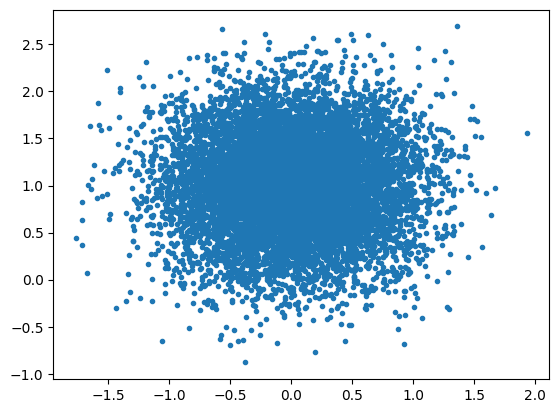

In [7]:
plt.plot(particles_locations[:, 0], particles_locations[:, 1], ".")

In [12]:
from qdots_qll.resamplers import LiuWestResampler

In [13]:
resampler = LiuWestResampler(boundaries=bnds, a=0.98)

In [31]:
# new_dist = dist
for _ in range(100):
    key, subkey = jax.random.split(key)
    new_dist = resampler.resample(subkey=subkey, distribution=new_dist)

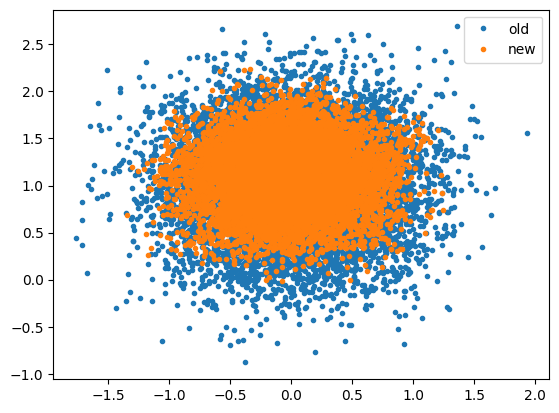

In [32]:
plt.plot(
    dist.particles_locations[:, 0], dist.particles_locations[:, 1], ".", label="old"
)
plt.plot(
    new_dist.particles_locations[:, 0],
    new_dist.particles_locations[:, 1],
    ".",
    label="new",
)
plt.legend()
plt.show()

In [37]:
from qdots_qll.smc import SMCUpdater

SMCUpdater()

qdots_qll.smc.SMCUpdater

In [49]:
no_exps = 20
key, subkey = jax.random.split(key)


chosen_initial_states = jax.random.choice(
    subkey, a=jnp.array([0, 1, 2, 3]), shape=(no_exps,)
)

key, subkey = jax.random.split(key)


chosen_measurement_basis = jax.random.choice(
    subkey, a=jnp.array([0, 1, 2]), shape=(no_exps,)
)


key, subkey = jax.random.split(key)


outcomes = jax.random.choice(
    subkey, a=jnp.array([0, 1]), shape=(no_exps,)
)

key, subkey = jax.random.split(key)


times = jax.random.uniform(subkey, shape=(no_exps,), minval=0.1, maxval=40.)

In [108]:
jax.random.uniform(subkey, minval=0.1, maxval=40.0).shape

()

In [103]:
from qdots_qll.models.single_dot_weak_coupling_GAME import ExperimentSingleDotWeakCouplingGAME
from qdots_qll.models.single_dot_weak_coupling_GAME import Data


i = 0
e0 = ExperimentSingleDotWeakCouplingGAME(t=times[i], initial_state=chosen_initial_states[i], measurement_basis=chosen_measurement_basis[i])
datum = Data(experiment=e0, outcome=outcomes[i])




In [63]:
structure = jax.tree.structure(e0)

In [66]:
vals, structure = jax.tree.flatten(e0)


ExperimentSingleDotWeakCouplingGAME(
  time=f32[1],
  initial_state=i32[1],
  measurement_basis=i32[1]
)

In [112]:
from qdots_qll.exp_design import RandExpDesignGAME


expdesign = RandExpDesignGAME()

In [156]:
key, subkey = jax.random.split(key)
e = expdesign.generate_experiment(subkey=subkey)
print(e)

Time [12.83877]
Initial state [1]
Measurement basis [1] 


In [161]:
Data(experiment=None, outcome=None).outcome

/home/antonio/dev/qdots_efficient/qdots_qll/utils/utils.py:5: FutureWarning: None encountered in jnp.array(); this is currently treated as NaN. In the future this will result in an error.
  array = jnp.array(array)


Array([nan], dtype=float32)

In [ ]:
from qdots_qll.exp_design import RandExpDesignGAME
from qdots_qll.models import single_dot_weak_coupling_GAME


model = single_dot_weak_coupling_GAME()
expdesign = RandExpDesignGAME()
resampler = 

In [166]:
jnp.empty_like(datum.experiment.time)

Array([0.], dtype=float32)

In [171]:
datum

Data(
  experiment=ExperimentSingleDotWeakCouplingGAME(
    time=f32[1],
    initial_state=i32[1],
    measurement_basis=i32[1]
  ),
  outcome=i32[1]
)

In [178]:
empty_exp = ExperimentSingleDotWeakCouplingGAME(t=None, initial_state=None, measurement_basis= None)

empty_outcome = jnp.nan

empty_data = Data(empty_exp, empty_outcome)

/home/antonio/dev/qdots_efficient/qdots_qll/utils/utils.py:5: FutureWarning: None encountered in jnp.array(); this is currently treated as NaN. In the future this will result in an error.
  array = jnp.array(array)


In [183]:
jnp.arange(20)

Array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19], dtype=int32)

In [173]:
iteration = 0

jax.lax.cond(iteration == 0, lambda data, datum: datum ,lambda data, datum: data,  *(data, datum))

TypeError: true_fun and false_fun output must have identical types, got
Experiment: Time DIFFERENT ShapedArray(float32[1]) vs. ShapedArray(float32[2])
Initial state DIFFERENT ShapedArray(int32[1]) vs. ShapedArray(int32[2])
Measurement basis DIFFERENT ShapedArray(int32[1]) vs. ShapedArray(int32[2]) 
outcome: DIFFERENT ShapedArray(int32[1]) vs. ShapedArray(int32[2]).

In [167]:
jnp.empty_like?

Signature:
jnp.empty_like(
    prototype: 'ArrayLike | DuckTypedArray',
    dtype: 'DTypeLike | None' = None,
    shape: 'Any' = None,
    *,
    device: 'xc.Device | Sharding | None' = None,
) -> 'Array'
Docstring:
Return a new array with the same shape and type as a given array.

LAX-backend implementation of :func:`numpy.empty_like`.

Because XLA cannot create uninitialized arrays, the JAX version will
return an array initialized with zeros.

*Original docstring below.*

Parameters
----------
prototype : array_like
    The shape and data-type of `prototype` define these same attributes
    of the returned array.
dtype : data-type, optional
    Overrides the data type of the result.
shape : int or sequence of ints, optional.
    Overrides the shape of the result. If order='K' and the number of
    dimensions is unchanged, will try to keep order, otherwise,
    order='C' is implied.

Returns
-------
out : ndarray
    Array of uninitialized (arbitrary) data with the same
    shape and 

In [153]:

key, subkey = jax.random.split(key=key)
experiment: Experiment = exp_design.generate_experiment(
            model=self.model,
            distribution=dist,
            data=data,
            subkey=subkey,
            *args,
            **kwargs,
        )


ExperimentSingleDotWeakCouplingGAME(
  time=f32[2],
  initial_state=i32[2],
  measurement_basis=i32[2]
)